# Major Project: Seasonal Agriculture Performance Analysis

### Data Analytics Project

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

This notebook follows a structured Data Analytics workflow:

**Data Understanding → Data Cleaning → Exploratory Data Analysis → Seasonal Comparison → Relationship Analysis → Statistical Analysis → Insights → Recommendations**

The project focuses on how agricultural performance varies across **Kharif, Rabi and Zaid seasons**, along with environmental conditions, resource usage and economic outcomes.

## 1. Introduction

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

The purpose of this project is to identify meaningful seasonal patterns, trends, relationships and differences in agricultural performance.

## 2. Problem Statement

Agricultural performance can change from one season to another because of differences in environmental conditions, farming practices, resource availability and market conditions.

The analysis therefore investigates:
- How agricultural performance varies across seasons
- Which seasonal patterns and trends are visible
- How environmental conditions and resource usage relate to outcomes
- How economic outcomes differ by season
- Whether patterns remain similar across crops, regions and irrigation methods
- What evidence-based conclusions and recommendations can be drawn from the data

## 3. Objectives

1. Explore and understand the dataset.
2. Clean and prepare the data for analysis.
3. Examine seasonal variation in agricultural performance.
4. Compare relevant groups across seasons.
5. Investigate relationships between environmental/resource variables and agricultural outcomes.
6. Identify significant differences or unusual patterns.
7. Apply statistical and visualization techniques.
8. Develop evidence-based insights and recommendations.

## 4. Analytical Questions

The following questions were developed from the project requirements:

1. Which season has the highest average yield?
2. How does profit vary across Kharif, Rabi and Zaid?
3. Which crops perform best in terms of yield and profit?
4. Does irrigation method appear to influence yield, profit and water efficiency?
5. How do rainfall, temperature, soil moisture and sunlight relate to yield?
6. Which season uses the most water, and which has the best water efficiency?
7. Are there meaningful differences in yield between seasons?
8. Which seasonal/crop combinations show unusually high or low performance?
9. What factors show the strongest association with yield?
10. What recommendations can be supported by the observed data?

## 5. Import Required Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 6. Load Dataset

In [38]:
DATA_FILE = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 4000
Columns: 28


## 7. Initial Data Understanding

In [39]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

First 5 Rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30



Data Types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [40]:
print("Unique values in important categorical columns:")

for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique())

Unique values in important categorical columns:

State: 8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District: 10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop: 8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season: 3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method: 4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 8. Data Quality Check

Before analysis, check for:
- Missing values
- Duplicate records
- Incorrect data types
- Potentially unrealistic values

Missing values are handled explicitly. Since `Yield_Tonnes_Ha` is the main performance outcome, rows with missing yield are excluded from outcome-based analysis rather than inventing yield values.

In [41]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})

display(missing_report[missing_report["Missing Values"] > 0])

print("Duplicate rows:", df.duplicated().sum())

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


Duplicate rows: 0


In [42]:
print("Basic descriptive statistics:")
display(df.describe(include="all").T)

Basic descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


## 9. Data Cleaning and Preparation

In [43]:
# Remove exact duplicate records
df_clean = df.drop_duplicates().copy()

# Yield is the main performance outcome.
# Keep only records where yield is available for outcome analysis.
df_clean = df_clean.dropna(subset=["Yield_Tonnes_Ha"]).copy()

# Impute remaining numeric missing values with their median.
numeric_cols = df_clean.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Original rows:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Remaining missing values:", int(df_clean.isna().sum().sum()))

Original rows: 4000
Rows after cleaning: 3968
Remaining missing values: 0


## 10. Descriptive Statistics

In [44]:
key_metrics = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

display(df_clean[key_metrics].describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"3,968.00",7.89,4.22,0.50,4.26,7.91,11.65,15.00
Rainfall_mm,"3,968.00",601.53,287.09,80.00,372.08,582.75,832.38,"1,395.20"
Avg_Temperature_C,"3,968.00",26.83,3.81,16.20,24.00,27.00,29.60,39.70
Soil_Moisture_pct,"3,968.00",26.53,6.67,8.00,21.80,26.50,31.30,47.00
Fertilizer_kg_ha,"3,968.00",185.91,60.29,40.00,143.80,186.15,227.03,400.00
Yield_Tonnes_Ha,"3,968.00",5.27,13.36,0.30,1.05,1.74,2.84,101.44
Production_Tonnes,"3,968.00",43.29,127.07,0.15,5.04,11.83,24.38,"1,424.40"
Revenue_INR,"3,968.00","638,135.48","637,342.64","6,107.00","209,122.25","456,830.50","834,879.75","5,080,900.00"
Profit_INR,"3,968.00","111,872.13","545,742.68","-1,019,223.00","-149,267.25","3,419.00","216,187.75","4,345,421.00"
Water_Used_m3,"3,968.00","6,038.88","5,567.51",128.00,"2,263.00","4,433.50","7,828.25","40,902.00"


## 10.1 Outlier Investigation

We will visualize the distribution of key numerical variables using box plots to identify potential outliers.

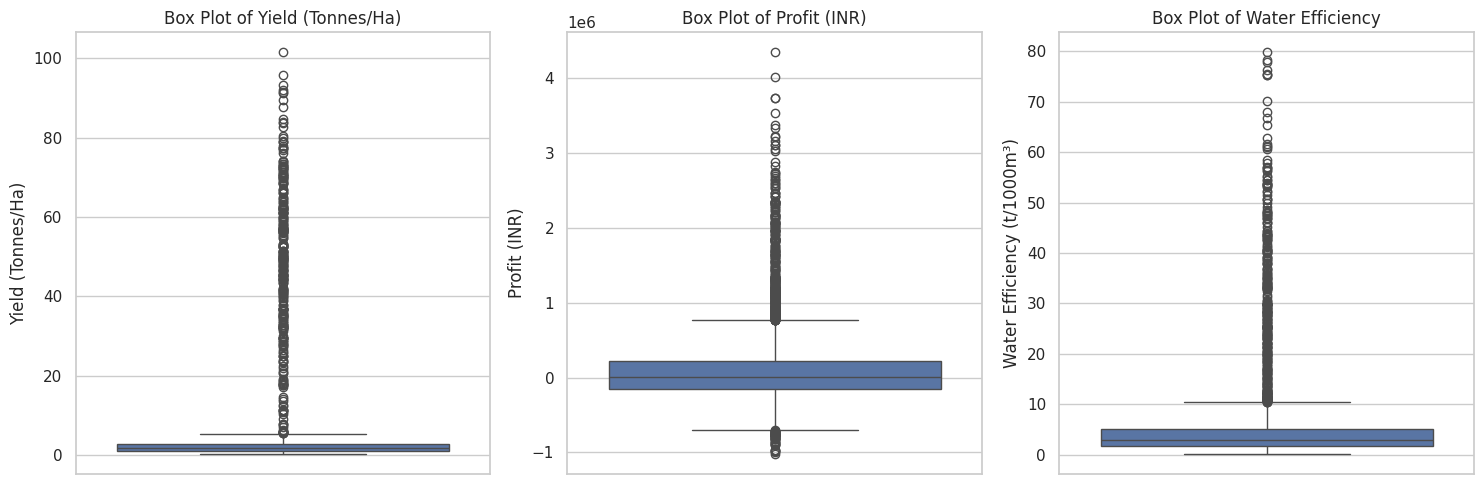

In [45]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean["Yield_Tonnes_Ha"])
plt.title("Box Plot of Yield (Tonnes/Ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.subplot(1, 3, 2)
sns.boxplot(y=df_clean["Profit_INR"])
plt.title("Box Plot of Profit (INR)")
plt.ylabel("Profit (INR)")

plt.subplot(1, 3, 3)
sns.boxplot(y=df_clean["Water_Efficiency_t_per_1000m3"])
plt.title("Box Plot of Water Efficiency")
plt.ylabel("Water Efficiency (t/1000m³)")

plt.tight_layout()
plt.show()


# 11. Univariate Analysis

Univariate analysis examines one variable at a time. The plots focus on seasonal distribution, important categorical variables, yield, profit and disease/pest risk.

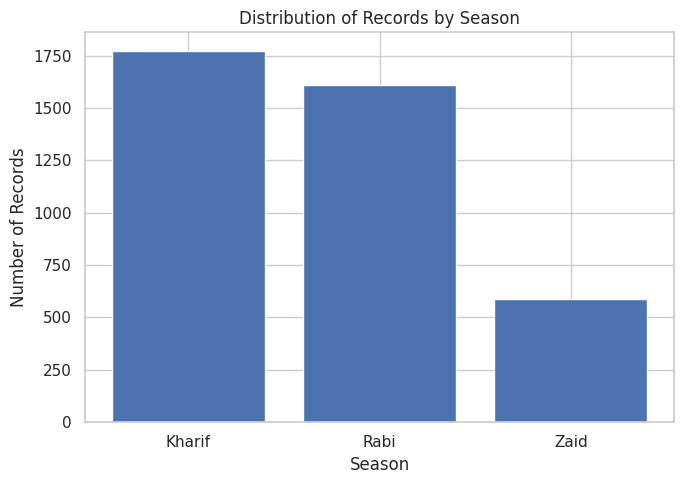

In [46]:
plt.figure(figsize=(7, 5))
season_counts = df_clean["Season"].value_counts()
plt.bar(season_counts.index, season_counts.values)
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

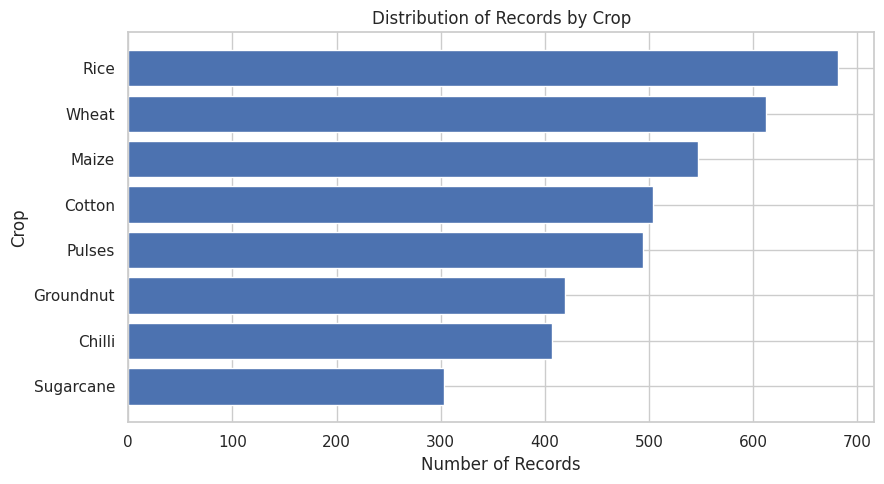

In [47]:
plt.figure(figsize=(9, 5))
crop_counts = df_clean["Crop"].value_counts().sort_values()
plt.barh(crop_counts.index, crop_counts.values)
plt.title("Distribution of Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

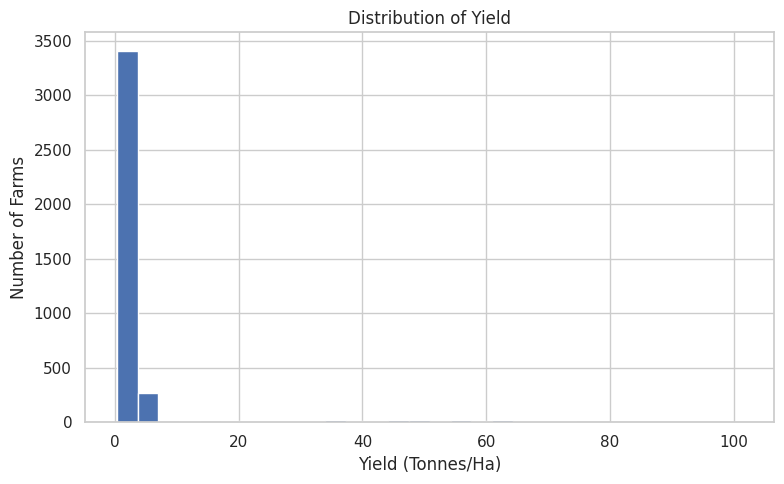

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Yield_Tonnes_Ha"], bins=30)
plt.title("Distribution of Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")
plt.tight_layout()
plt.show()

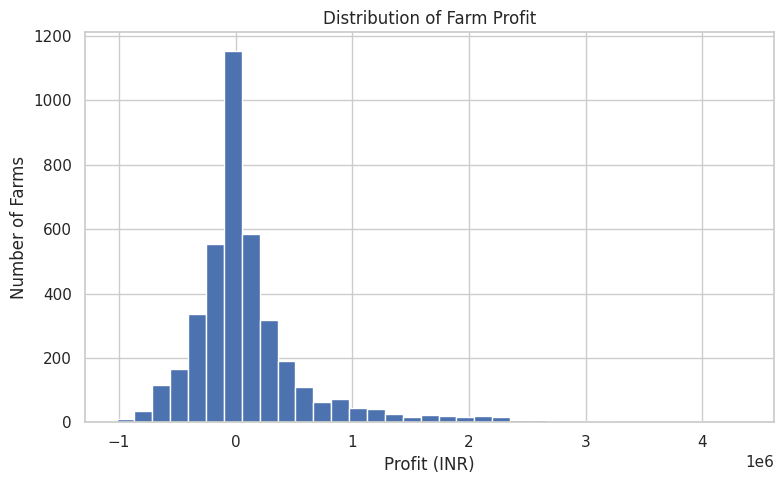

In [49]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Profit_INR"], bins=35)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Number of Farms")
plt.tight_layout()
plt.show()

# 12. Seasonal Performance Analysis

This is the central part of the project. We compare yield, production, revenue, profit, water usage, water efficiency and disease/pest risk across seasons.

In [50]:
season_summary = df_clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Yield_Tonnes_Ha", ascending=False)

display(season_summary.round(2))

,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
Season,,,,,,,,
Kharif,1772,5.64,46.44,"711,441.28","179,367.12","6,094.05",5.91,54.47
Rabi,1607,5.08,41.34,"601,825.55","88,197.25","5,837.24",5.18,40.52
Zaid,589,4.67,39.15,"516,662.12","-26,592.40","6,423.08",4.44,38.22


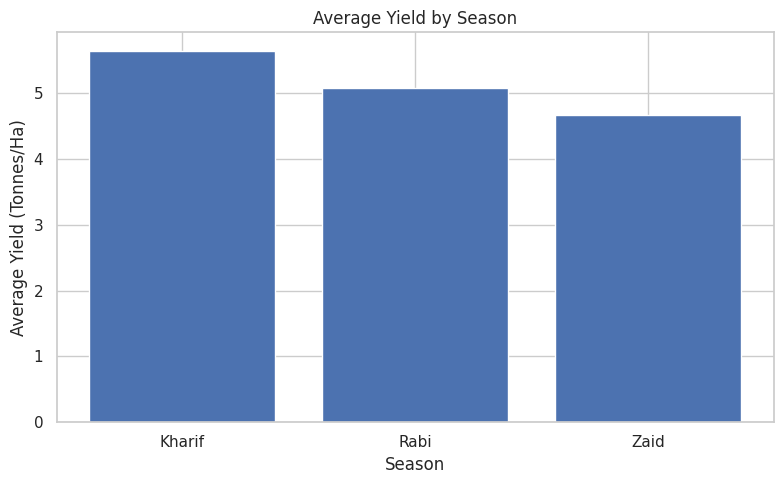

In [51]:
plt.figure(figsize=(8, 5))
season_yield = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
plt.bar(season_yield.index, season_yield.values)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

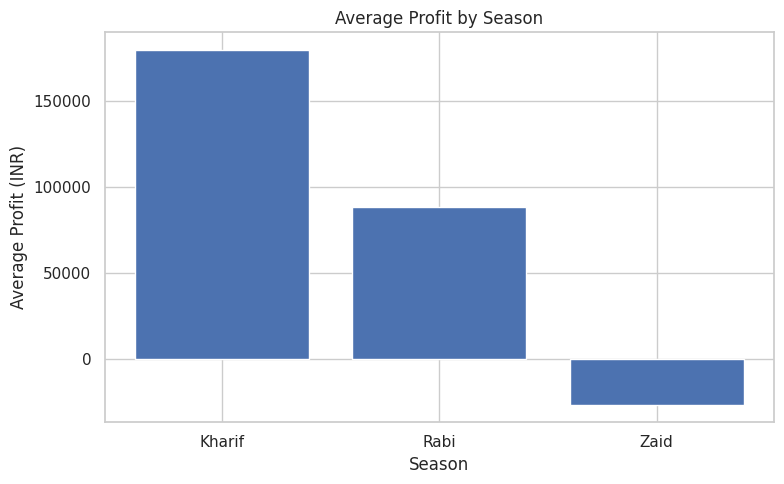

In [52]:
plt.figure(figsize=(8, 5))
season_profit = df_clean.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)
plt.bar(season_profit.index, season_profit.values)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

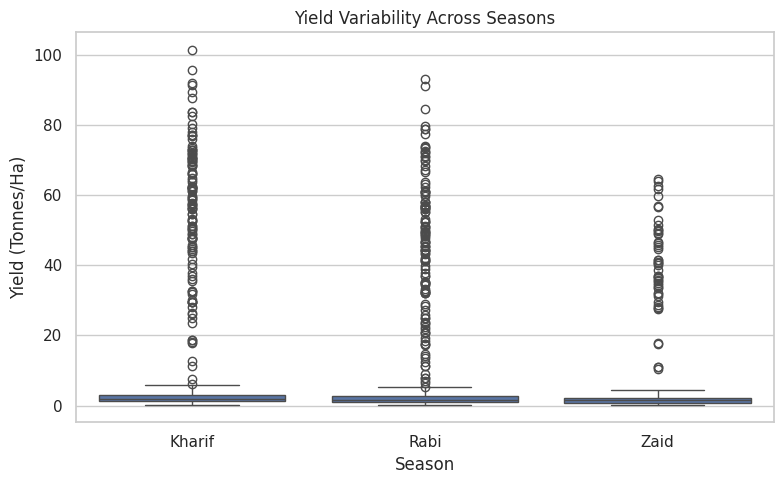

In [53]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Variability Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 13. Crop-wise and Season-wise Comparison

In [54]:
crop_summary = df_clean.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean")
).sort_values("Avg_Yield", ascending=False)

display(crop_summary.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Revenue
Crop,,,,
Sugarcane,303,46.94,"817,245.40","1,371,942.16"
Maize,547,2.72,"-82,749.43","455,816.70"
Rice,682,2.44,"-101,405.00","424,419.24"
Wheat,612,2.11,"-123,567.97","401,021.80"
Chilli,407,1.54,"753,377.50","1,277,626.67"
Groundnut,419,1.32,"44,604.38","543,404.37"
Cotton,504,1.23,"124,969.85","640,747.78"
Pulses,494,0.92,"-3,987.21","529,544.02"


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


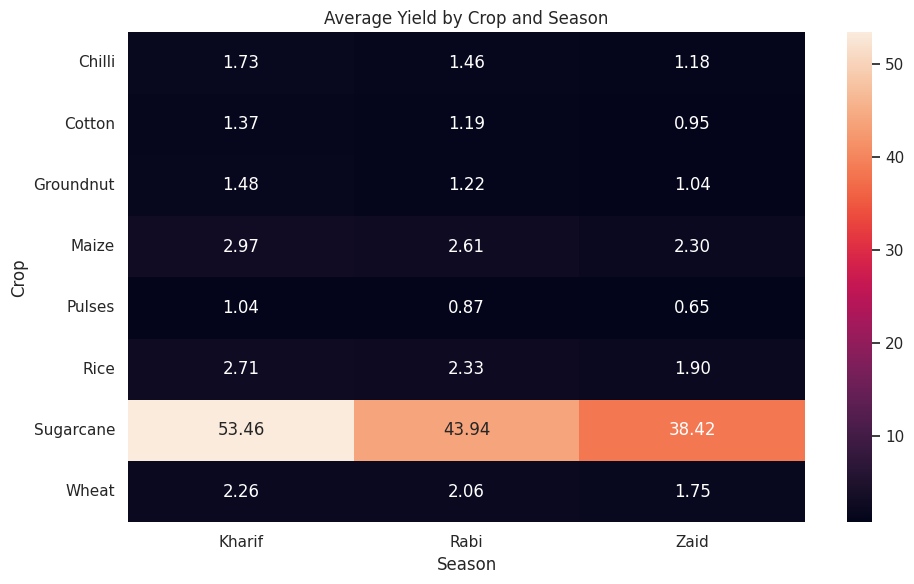

In [55]:
crop_season_yield = df_clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

display(crop_season_yield.round(2))

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [56]:
crop_season_profit = df_clean.groupby(["Crop", "Season"]).agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).reset_index()

display(
    crop_season_profit
    .sort_values("Avg_Yield", ascending=False)
    .head(15)
    .round(2)
)

,Crop,Season,Farms,Avg_Yield,Avg_Profit
18,Sugarcane,Kharif,125,53.46,"1,000,790.81"
19,Sugarcane,Rabi,127,43.94,"730,402.20"
20,Sugarcane,Zaid,51,38.42,"583,635.80"
9,Maize,Kharif,234,2.97,"-39,332.67"
15,Rice,Kharif,311,2.71,"-65,529.83"
10,Maize,Rabi,230,2.61,"-87,830.88"
16,Rice,Rabi,269,2.33,"-95,167.37"
11,Maize,Zaid,83,2.30,"-191,072.20"
21,Wheat,Kharif,291,2.26,"-106,005.81"
22,Wheat,Rabi,236,2.06,"-120,140.46"


## 14. Environmental Conditions and Yield

We investigate whether rainfall, temperature, humidity, sunlight and soil moisture show noticeable relationships with yield.

**Important:** correlation indicates association, not causation.

In [57]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

env_corr = df_clean[environment_cols + ["Yield_Tonnes_Ha"]].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)
display(env_corr.to_frame("Correlation with Yield"))

,Correlation with Yield
Yield_Tonnes_Ha,1.00
Rainfall_mm,0.03
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Sunlight_Hours_Day,-0.02
Soil_pH,-0.02


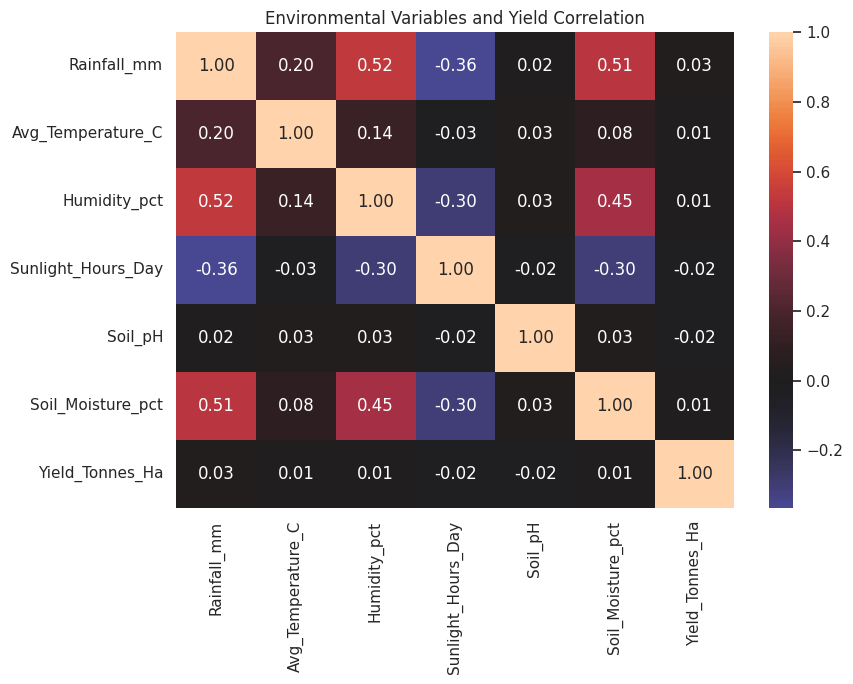

In [58]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    df_clean[environment_cols + ["Yield_Tonnes_Ha"]].corr(),
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Environmental Variables and Yield Correlation")
plt.tight_layout()
plt.show()

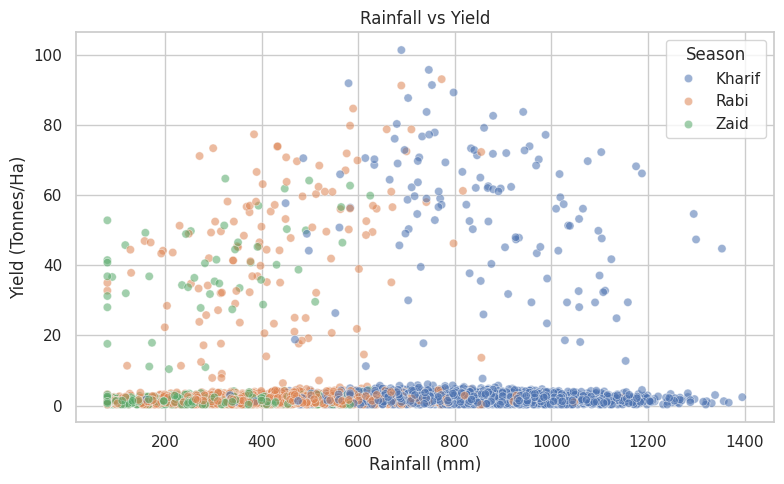

In [59]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.55)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

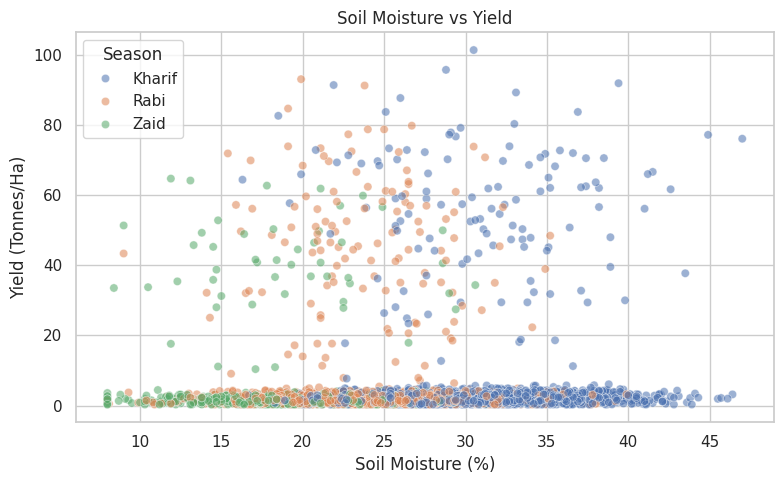

In [60]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="Soil_Moisture_pct", y="Yield_Tonnes_Ha", hue="Season", alpha=0.55)
plt.title("Soil Moisture vs Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 15. Resource Usage and Irrigation Analysis

In [61]:
irrigation_summary = df_clean.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield", ascending=False)

display(irrigation_summary.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,907,6.62,"219,002.41","5,901.44",6.23
Sprinkler,728,5.19,"93,844.83","6,210.70",4.69
Flood,1296,4.90,"72,918.99","8,028.81",3.46
Rainfed,1037,4.61,"79,509.51","3,551.55",7.57


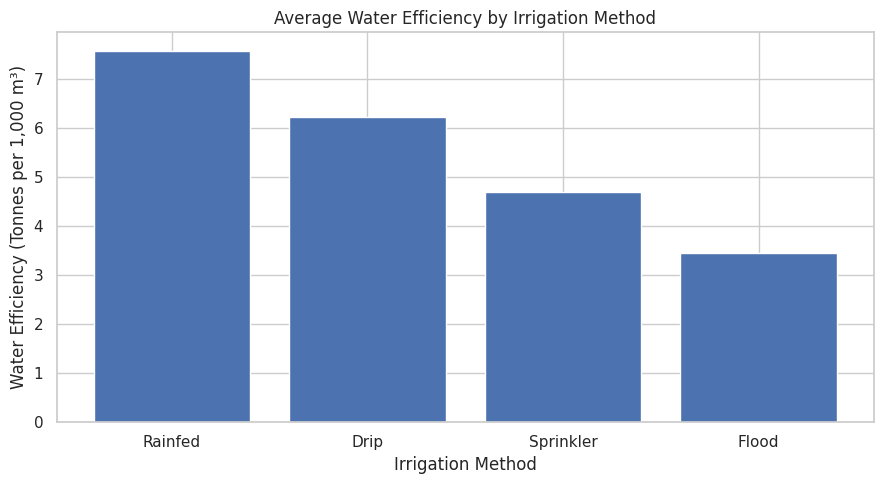

In [62]:
plt.figure(figsize=(9, 5))
irrigation_eff = df_clean.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)
plt.bar(irrigation_eff.index, irrigation_eff.values)
plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.tight_layout()
plt.show()

In [63]:
resource_season = df_clean.groupby("Season").agg(
    Avg_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Avg_Pesticide=("Pesticide_Litre_ha", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
)

display(resource_season.round(2))

,Avg_Fertilizer,Avg_Pesticide,Avg_Water_Used,Avg_Water_Efficiency
Season,,,,
Kharif,187.04,5.08,"6,094.05",5.91
Rabi,185.28,5.03,"5,837.24",5.18
Zaid,184.23,5.16,"6,423.08",4.44


## 16. Economic Performance Analysis

In [64]:
economic_summary = df_clean.groupby("Season").agg(
    Avg_Market_Price=("Market_Price_INR_Tonne", "mean"),
    Avg_Total_Cost=("Total_Cost_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean")
).sort_values("Avg_Profit", ascending=False)

display(economic_summary.round(2))

,Avg_Market_Price,Avg_Total_Cost,Avg_Revenue,Avg_Profit
Season,,,,
Kharif,"44,846.63","532,074.15","711,441.28","179,367.12"
Rabi,"44,770.59","513,628.29","601,825.55","88,197.25"
Zaid,"43,957.76","543,254.52","516,662.12","-26,592.40"


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"959,407.00","641,573.00","432,268.00"
Cotton,"216,143.00","106,995.00","-50,130.00"
Groundnut,"108,374.00","9,252.00","-68,872.00"
Maize,"-39,333.00","-87,831.00","-191,072.00"
Pulses,"43,339.00","-14,433.00","-139,146.00"
Rice,"-65,530.00","-95,167.00","-227,239.00"
Sugarcane,"1,000,791.00","730,402.00","583,636.00"
Wheat,"-106,006.00","-120,140.00","-193,209.00"


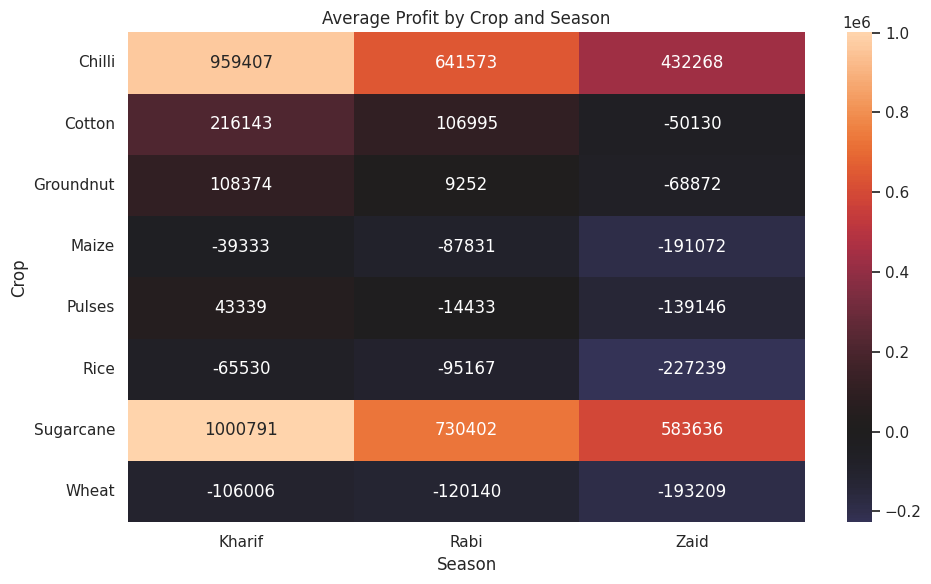

In [65]:
profit_pivot = df_clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
)

display(profit_pivot.round(0))

plt.figure(figsize=(10, 6))
sns.heatmap(profit_pivot, annot=True, fmt=".0f", center=0)
plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

## 17. Profitability Distribution and Loss-making Farms

,Loss-making Farms (%)
Season,
Zaid,64.52
Rabi,51.28
Kharif,42.27


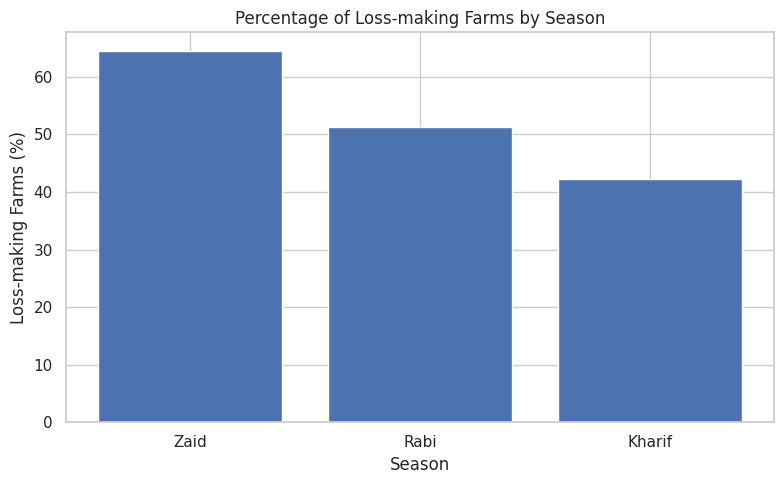

In [66]:
loss_rate = (
    df_clean.assign(Loss=df_clean["Profit_INR"] < 0)
    .groupby("Season")["Loss"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(loss_rate.to_frame("Loss-making Farms (%)").round(2))

plt.figure(figsize=(8, 5))
plt.bar(loss_rate.index, loss_rate.values)
plt.title("Percentage of Loss-making Farms by Season")
plt.xlabel("Season")
plt.ylabel("Loss-making Farms (%)")
plt.tight_layout()
plt.show()

## 18. Strongest Numeric Associations with Yield

In [67]:
numeric_corr = (
    df_clean.select_dtypes(include=np.number)
    .corr()["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(numeric_corr.head(12).to_frame("Correlation with Yield"))

,Correlation with Yield
Water_Efficiency_t_per_1000m3,0.92
Production_Tonnes,0.89
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,-0.38
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Total_Cost_INR,0.03
Rainfall_mm,0.03


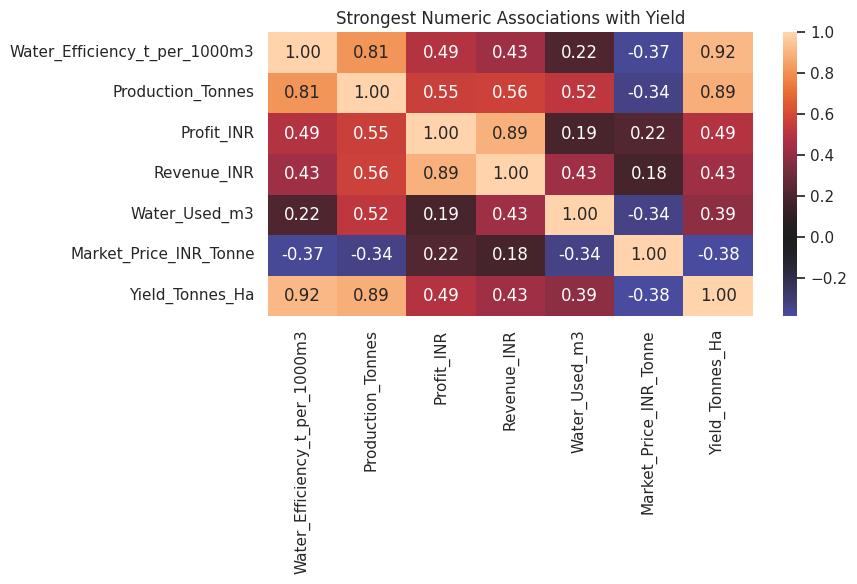

In [68]:
top_corr_cols = numeric_corr.head(6).index.tolist()

plt.figure(figsize=(9, 6))
sns.heatmap(
    df_clean[top_corr_cols + ["Yield_Tonnes_Ha"]].corr(),
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Strongest Numeric Associations with Yield")
plt.tight_layout()
plt.show()

## 19. Identify High- and Low-Performing Seasonal Groups

In [69]:
group_performance = df_clean.groupby(["Season", "Crop"]).agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reset_index()

print("Top 10 groups by average yield:")
display(group_performance.sort_values("Avg_Yield", ascending=False).head(10).round(2))

print("Bottom 10 groups by average yield:")
display(group_performance.sort_values("Avg_Yield", ascending=True).head(10).round(2))

Top 10 groups by average yield:


,Season,Crop,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
6,Kharif,Sugarcane,125,53.46,"1,000,790.81",36.00
14,Rabi,Sugarcane,127,43.94,"730,402.20",27.86
22,Zaid,Sugarcane,51,38.42,"583,635.80",23.39
3,Kharif,Maize,234,2.97,"-39,332.67",6.05
5,Kharif,Rice,311,2.71,"-65,529.83",2.17
11,Rabi,Maize,230,2.61,"-87,830.88",5.44
13,Rabi,Rice,269,2.33,"-95,167.37",1.85
19,Zaid,Maize,83,2.30,"-191,072.20",4.79
7,Kharif,Wheat,291,2.26,"-106,005.81",4.76
15,Rabi,Wheat,236,2.06,"-120,140.46",4.69


Bottom 10 groups by average yield:


,Season,Crop,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
20,Zaid,Pulses,61,0.65,"-139,145.54",1.97
12,Rabi,Pulses,212,0.87,"-14,432.54",2.70
17,Zaid,Cotton,91,0.95,"-50,129.58",1.50
4,Kharif,Pulses,221,1.04,"43,338.90",3.35
18,Zaid,Groundnut,54,1.04,"-68,872.50",2.47
16,Zaid,Chilli,62,1.18,"432,267.81",2.21
9,Rabi,Cotton,199,1.19,"106,995.30",1.94
10,Rabi,Groundnut,173,1.22,"9,252.21",2.90
1,Kharif,Cotton,214,1.37,"216,142.67",2.13
8,Rabi,Chilli,161,1.46,"641,572.55",2.90


## 20. Key Findings

The next cell generates a concise evidence-based summary directly from the dataset, so the final observations update automatically if the data changes.

In [70]:
best_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
best_profit_season = season_summary["Avg_Profit_INR"].idxmax()
best_water_eff_season = season_summary["Avg_Water_Efficiency"].idxmax()
highest_water_season = season_summary["Avg_Water_Used_m3"].idxmax()

best_crop = crop_summary["Avg_Yield"].idxmax()
best_profit_crop = crop_summary["Avg_Profit"].idxmax()
best_irrigation_yield = irrigation_summary["Avg_Yield"].idxmax()
best_irrigation_eff = irrigation_summary["Avg_Water_Efficiency"].idxmax()

print(f"1. Highest average yield season: {best_yield_season} ({season_summary.loc[best_yield_season, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha)")
print(f"2. Highest average profit season: {best_profit_season} (₹{season_summary.loc[best_profit_season, 'Avg_Profit_INR']:,.0f})")
print(f"3. Best average water-efficiency season: {best_water_eff_season} ({season_summary.loc[best_water_eff_season, 'Avg_Water_Efficiency']:.2f} tonnes/1,000 m³)")
print(f"4. Highest average water use: {highest_water_season} ({season_summary.loc[highest_water_season, 'Avg_Water_Used_m3']:,.0f} m³)")
print(f"5. Highest-yielding crop on average: {best_crop} ({crop_summary.loc[best_crop, 'Avg_Yield']:.2f} tonnes/ha)")
print(f"6. Highest-profit crop on average: {best_profit_crop} (₹{crop_summary.loc[best_profit_crop, 'Avg_Profit']:,.0f})")
print(f"7. Irrigation method with highest average yield: {best_irrigation_yield}")
print(f"8. Irrigation method with highest average water efficiency: {best_irrigation_eff}")

print("\nInterpretation note:")
print("These are associations and group comparisons in this dataset. They should not be interpreted as proof that one factor causes another.")

1. Highest average yield season: Kharif (5.64 tonnes/ha)
2. Highest average profit season: Kharif (₹179,367)
3. Best average water-efficiency season: Kharif (5.91 tonnes/1,000 m³)
4. Highest average water use: Zaid (6,423 m³)
5. Highest-yielding crop on average: Sugarcane (46.94 tonnes/ha)
6. Highest-profit crop on average: Sugarcane (₹817,245)
7. Irrigation method with highest average yield: Drip
8. Irrigation method with highest average water efficiency: Rainfed

Interpretation note:
These are associations and group comparisons in this dataset. They should not be interpreted as proof that one factor causes another.


## 21. Data-Driven Recommendations

Based on the analysis of seasonal, crop, irrigation, environmental, resource and economic performance:

1. **Prioritize stronger-performing seasons for planning.**  
   Use observed differences in yield and profitability to support seasonal planning, while recognizing that descriptive comparisons do not establish statistical significance.

2. **Consider crop-season combinations rather than only overall crop averages.**  
   Overall crop averages can hide differences between seasons. Therefore, crop performance should be evaluated together with the season in which the crop is cultivated.

3. **Evaluate irrigation using both productivity and water efficiency.**  
   An irrigation method with higher yield is not automatically the most water-efficient. Both productivity and water usage should be considered when comparing irrigation methods.

4. **Give attention to highly profitable crop groups.**  
   Crop groups with stronger average profit can be considered for planning, but profitability should also be evaluated alongside production costs and resource requirements.

5. **Monitor loss-making crop-season combinations.**  
   Crop-season groups with negative average profit should receive additional investigation into yield, production cost, resource consumption and revenue patterns.

6. **Use environmental and resource indicators together.**  
   Relationships between rainfall, temperature, soil conditions, fertilizer use, water use and yield can help identify performance patterns. However, observed correlations should be treated as associations and not as proof of causation.


## 21.1 Limitations

This analysis is based on the provided dataset and has certain limitations:

1.  **Correlation vs. Causation:** While the analysis identifies correlations between variables (e.g., environmental factors and yield), it does not establish causation. Further controlled experiments or more complex modeling would be required to infer causal relationships.
2.  **Data Scope:** The dataset covers specific states, districts, crops, and seasons. The findings may not be generalizable to other regions, crops, or agricultural contexts not represented in the data.
3.  **Time Period:** The analysis is based on a snapshot of data. Seasonal patterns and relationships could change over longer timeframes due to factors like climate change, technological advancements, or shifting market conditions.
4.  **Granularity:** The data is at a farm level, which provides valuable insights. However, more granular data (e.g., daily sensor data, specific farming practices within a season) could offer deeper insights into performance drivers.
5.  **Missing Data Strategy:** While missing values were handled, the imputation strategy (median for numerical) might introduce biases if the missingness is not completely random.
6.  **Outlier Impact:** Although outliers were visualized, their specific impact on certain analyses was not explicitly quantified or rigorously addressed (e.g., through robust statistical methods or transformation). While the plots give an indication, a deeper dive into specific outliers might reveal data entry errors or unusual but valid conditions.

## 22. Conclusion

This analysis examines seasonal agricultural performance using farm-level data. It combines data cleaning, descriptive statistics, univariate analysis, seasonal comparisons, crop and irrigation analysis, correlation analysis and visualization.

The final conclusions should be based on the generated tables and charts. The analysis highlights how agricultural performance can vary across seasons and how yield, economic outcomes, environmental conditions and resource usage can be studied together to support evidence-based seasonal agricultural planning.
